In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

In [6]:
np.random.seed(0)
X = np.random.rand(200,1) - 0.5
y = 2 * X[:, 0]**2 + 0.05 * np.random.randn(200)

In [7]:
df = pd.DataFrame({
    'X' : X.reshape(200),
    'y' : y
})
df.head()

,X,y
0,0.048814,0.061097
1,0.215189,0.038616
2,0.102763,-0.036253
3,0.044883,-0.017862
4,-0.076345,-0.013244


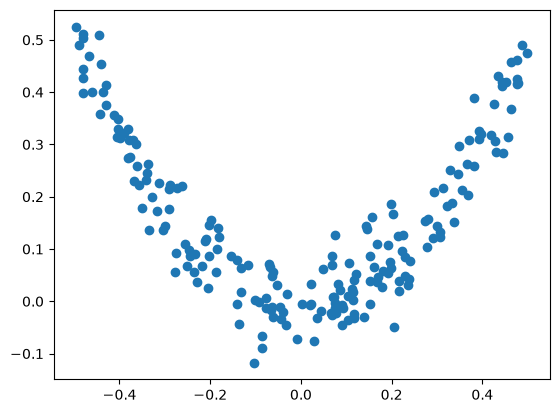

In [8]:
plt.scatter(df['X'], df['y'])
plt.show()

# Gradient Boosting 
### The first model of the GB Regression will predict the mean of the output.

In [ ]:
# 1st Model
df['pred1'] = df['y'].mean()

### To calculate the loss it uses the pseudo-residual 
### `pseudo-residual = actual - prediction`

In [10]:
df['res1'] = df['y'] - df['pred1']
df['res1']

0     -0.094504
1     -0.116984
2     -0.191854
3     -0.173463
4     -0.168845
         ...   
195   -0.227308
196    0.061231
197   -0.069392
198    0.202461
199   -0.173058
Name: res1, Length: 200, dtype: float64

### From the second model it uses the base estimator and predicts the residual of the previous model.

In [ ]:
# 2nd Model
tree1 = DecisionTreeRegressor(max_leaf_nodes=10, random_state=0)

tree1.fit(df['X'].values.reshape(200,1), df['res1'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

### This is not the final prediction, so final prediction after 2nd model is
### `pred2 = pred1 + learning_rate * pred_of_model2` 

In [ ]:
lr = 0.1 # Learning Rate

# Prediction After 2nd Model
df['pred2'] = df['pred1'] + lr * tree1.predict(df['X'].values.reshape(200,1))

# Residual After 2nd Model
df['res2'] = df['y'] - df['pred2']

df.head()

,X,y,pred1,res1,pred2,res2
0,0.048814,0.061097,0.155601,-0.094504,0.140202,-0.079105
1,0.215189,0.038616,0.155601,-0.116984,0.147637,-0.109021
2,0.102763,-0.036253,0.155601,-0.191854,0.140202,-0.176455
3,0.044883,-0.017862,0.155601,-0.173463,0.140202,-0.158064
4,-0.076345,-0.013244,0.155601,-0.168845,0.140202,-0.153447


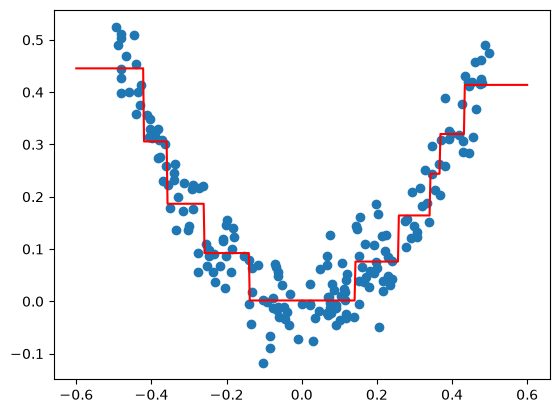

In [15]:
X_test = np.linspace(-0.6, 0.6, 500)

y_pred = df['y'].mean() + tree1.predict(X_test.reshape(500,1))

plt.plot(X_test, y_pred, color = 'red')
plt.scatter(df['X'], df['y'])
plt.show()

### For 3rd model do the same it trys to predict the residual of the 2nd model.
### The final prediction after the 3rd model :
### `pred3 = pred1 + lr * (pred2 + pred3)`

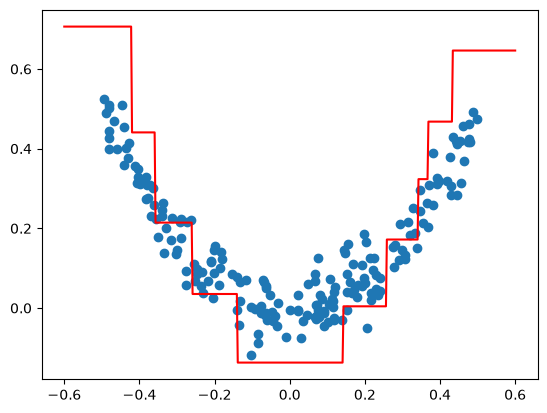

In [22]:
# 3rd Model
tree2 = DecisionTreeRegressor(max_leaf_nodes=10, random_state = 0)

tree2.fit(df['X'].values.reshape(200,1), df['res2'].values)

y_pred = df['y'].mean() + sum(reg.predict(X_test.reshape(500,1)) for reg in [tree1, tree2])

plt.plot(X_test, y_pred, color = 'red')
plt.scatter(df['X'], df['y'])
plt.show()

### General Eq for the final prediction after the N D.T.s is 
### `y_pred = m_1 + lr * Σ m_i`
 Where m_i = prediction of the ith model

5


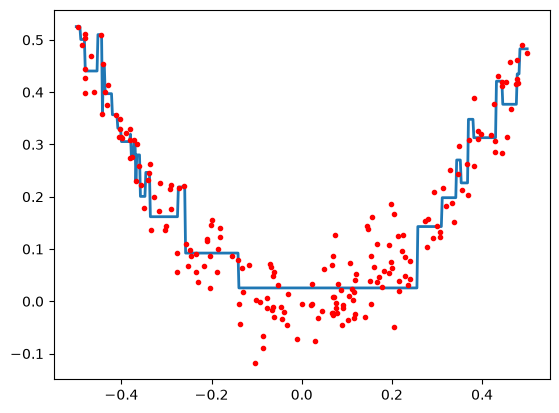

4


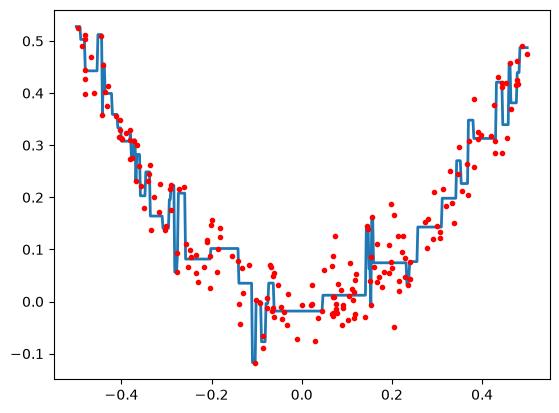

3


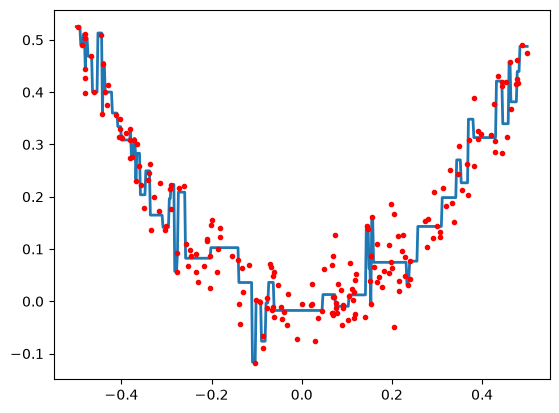

2


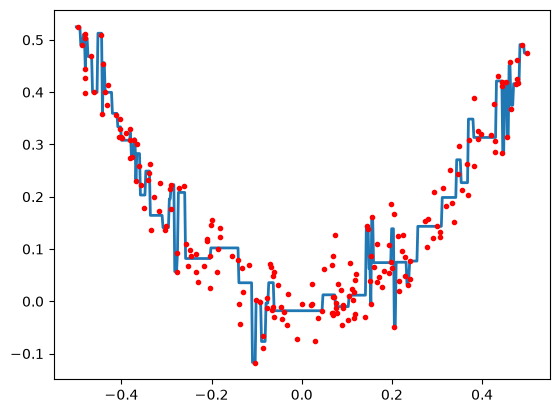

1


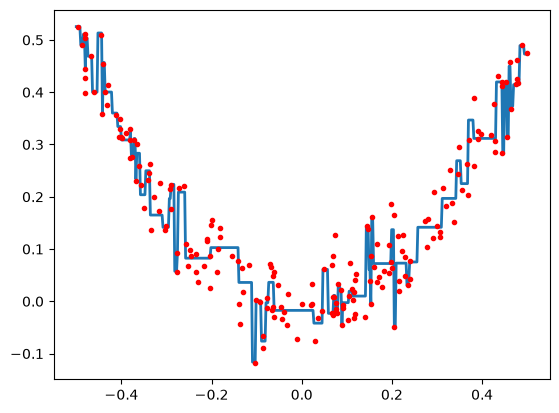

In [23]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return 
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)

gradient_boost(X,y,5,lr=1)

### Basic Example of Gradient Boostint Regressor in the Sklearn

In [28]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

reg = GradientBoostingRegressor()

reg.fit(df['X'].values.reshape(200,1), df['y'].values)

mean_squared_error(df['y'].values, reg.predict(df['X'].values.reshape(200,1)))

0.0009367886091656267